<a href="https://colab.research.google.com/github/stephenbeckr/functional-Liu/blob/main/scripts/compare_GCV_to_testMSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic script to show how to use `fliu` package
and to validate code, and check that GCV is a good proxy for MSE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [52]:
# Here are the versions of python and the packages that we use
# print('Numpy version ' + np.__version__)
# import scipy
# print('Scipy version ' + scipy.__version__)
# import jax
# print('Jax version ' + jax.__version__)
# import pandas as pd
# print('Pandas version ' + pd.__version__)
# import matplotlib
# print('Matplotlib version ' + matplotlib.__version__)

Numpy version 2.0.2
Scipy version 1.16.3
Jax version 0.7.2
Pandas version 2.2.2
Matplotlib version 3.10.0


Install the `fliu` package from github

In [2]:
!wget -q https://github.com/stephenbeckr/functional-Liu/raw/refs/heads/main/fliu.py
import fliu

Helper code:

In [3]:
def simulate_data(n, p, sigma2, rho=0.6, seed=0, n_test=1000):
    """ sigma2 is *variance* of the additive noise """
    rng = np.random.default_rng(seed)

    if p > n:
        raise ValueError("p must be greater than n")

    # AR(1) covariance
    Sigma = rho ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))
    print(f'Condition number of Sigma is {np.linalg.cond(Sigma):.2e}')

    beta_true = rng.normal(size=p)

    X = rng.multivariate_normal(np.zeros(p), Sigma, size=n)
    y = X @ beta_true
    noise = np.sqrt(sigma2)*rng.normal(size=n)
    snr = 20*np.log10( np.linalg.norm(y) / np.linalg.norm(noise) )
    print(f'SNR in dB is {snr:.2f}') # Changed printf to print
    y += noise

    X_test = rng.multivariate_normal(np.zeros(p), Sigma, size=n_test)
    y_test = X_test @ beta_true + np.sqrt(sigma2)*rng.normal(size=n_test)

    return X, y, X_test, y_test

## Basic check to make sure that the code runs smoothly

In [51]:
n   = 100
p   = 50
rho = 0.6

X, y, X_test, y_test = simulate_data(n,p, sigma2=10, rho=rho, seed=0 )
R = fliu.second_difference_matrix(p)
test_mse = lambda beta : np.mean((X_test @ beta - y_test)**2)

beta, gcv = fliu.ols(X,y)
print(f'For OLS,\tgcv is {gcv:.2f} and test MSE is {test_mse(beta):.2f}')

beta, gcv, lam_optimal = fliu.ridge(X,y)
print(f'For Ridge,\tgcv is {gcv:.2f} and test MSE is {test_mse(beta):.2f}')

beta, gcv, lam_optimal, d_optimal = fliu.classical_liu(X,y)
print(f'For Liu,\tgcv is {gcv:.2f} and test MSE is {test_mse(beta):.2f}')

beta, gcv, lam_optimal, alpha_optimal = fliu.cardot(X,y,R)
print(f'For Cardot,\tgcv is {gcv:.2f} and test MSE is {test_mse(beta):.2f}')

beta, gcv, lam_optimal, d_optimal, alpha_optimal = fliu.functional_liu(X,y,R)
print(f'For fLiu,\tgcv is {gcv:.2f} and test MSE is {test_mse(beta):.2f}')

print(f'For fLiu, {lam_optimal=:.3f}, {d_optimal=:.3f}, {alpha_optimal=:.3f}')

Condition number of Sigma is 1.58e+01
SNR in dB is 8.49
For OLS,	gcv is 24.72 and test MSE is 22.47
For Ridge,	gcv is 18.80 and test MSE is 15.98
For Liu,	gcv is 18.77 and test MSE is 16.00
For Cardot,	gcv is 18.68 and test MSE is 15.98
For fLiu,	gcv is 18.40 and test MSE is 15.88
For fLiu, lam_optimal=25.832, d_optimal=0.334, alpha_optimal=0.644


## Check that minimizing GCV is working
i.e., that our optimzier does find the minimum, and that minimizing GCV is a good proxy for minimizing the test error

Note: we have a parameter named "lambda" ($\lambda$) but in Python, the word "lambda" is a special keyword, so instead we refer to $\lambda$ as "lam"

In [43]:
def plot_results( results_train, results_test, results_gcv, param_opt, gcv_opt, d_grid, title, x_label = 'd' ):
    results_train = np.asarray(results_train)
    results_test  = np.asarray(results_test)
    results_gcv   = np.asarray(results_gcv)
    # Plot
    plt.plot(d_grid, results_train, label="training error")
    line, = plt.plot(d_grid, results_test, label="testing error")
    idx = np.argmin(results_test)
    plt.plot(d_grid[idx], results_test[idx],"s",color=line.get_color(),label="minimum test")
    line, = plt.plot(d_grid, results_gcv, "--", label="GCV")
    plt.plot(param_opt,gcv_opt,"o",color=line.get_color(),label="optimizer")
    plt.yscale("log")
    if d_grid[-1]/d_grid[-2] > 1.1*d_grid[-2]/d_grid[-3]:
        plt.xscale("log")
    plt.xlabel(x_label)
    plt.title(title)
    plt.legend()
    plt.show()

As a function of $d$

Condition number of Sigma is 1.58e+01
SNR in dB is 8.49


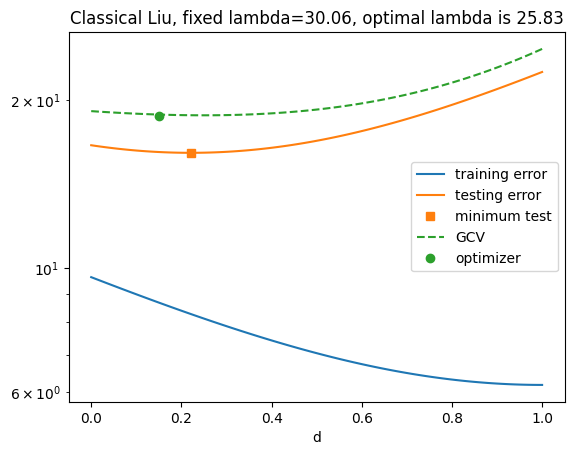

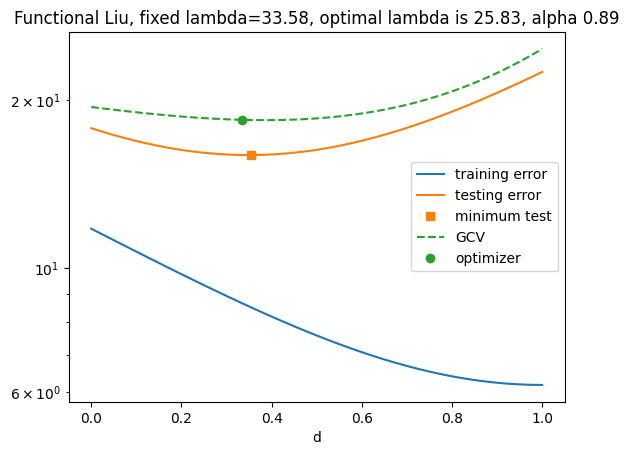

In [44]:
n   = 100
p   = 50
rho = 0.6

X, y, X_test, y_test = simulate_data(n,p, sigma2=10, rho=rho, seed=0 )
R = fliu.second_difference_matrix(p)
test_mse  = lambda beta : np.mean((X_test @ beta - y_test)**2)
train_mse = lambda beta : np.mean((X @ beta - y)**2)

# == Classical Liu ==
results_train = []
results_test  = []
results_gcv   = []
beta, gcv_opt, lam_opt, d_opt = fliu.classical_liu(X,y ) # search for params
lam    = 1.3*lam_opt  # fix any value
d_grid = np.linspace(0, 1, 100)
for d in d_grid:
    beta, gcv = fliu.classical_liu(X,y, (lam,d) )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
title = f"Classical Liu, fixed lambda={lam:.2f}, optimal lambda is {lam_optimal:.2f}"
plot_results( results_train, results_test, results_gcv, d_opt, gcv_opt, d_grid, title )

# == functional Liu ==
results_train = []
results_test  = []
results_gcv   = []
beta, gcv_opt, lam_opt, d_opt, alpha_opt = fliu.functional_liu(X,y,R) # search for params
lam    = 1.3*lam_opt  # fix any value
alpha  = 0.9*alpha_opt
d_grid = np.linspace(0, 1, 100)
for d in d_grid:
    beta, gcv = fliu.functional_liu(X,y,R,(lam,d,alpha) )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
title = f"Functional Liu, fixed lambda={lam:.2f}, optimal lambda is {lam_optimal:.2f}, alpha {alpha_optimal:.2f}"
plot_results( results_train, results_test, results_gcv, d_opt, gcv_opt, d_grid, title )

As a function of $\lambda$

Condition number of Sigma is 3.02e+02
SNR in dB is 10.28


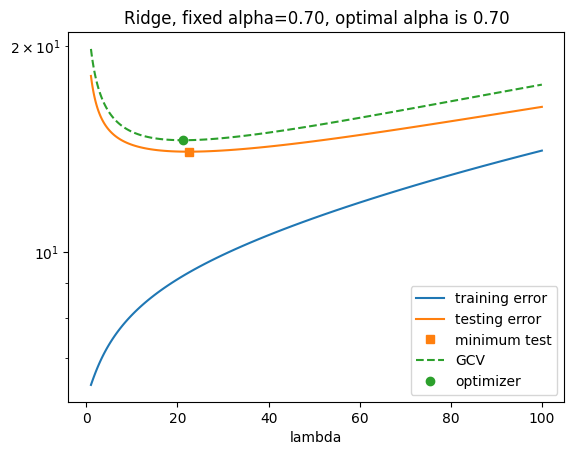

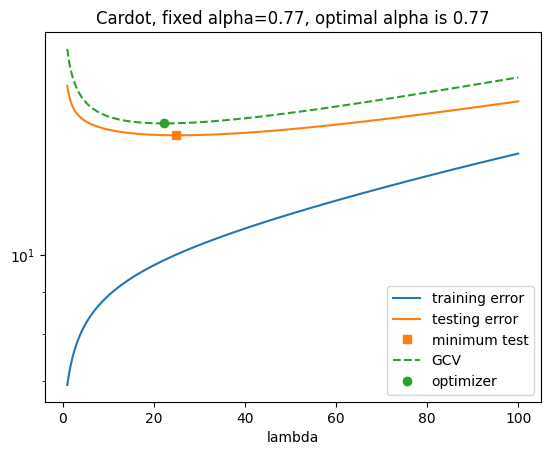

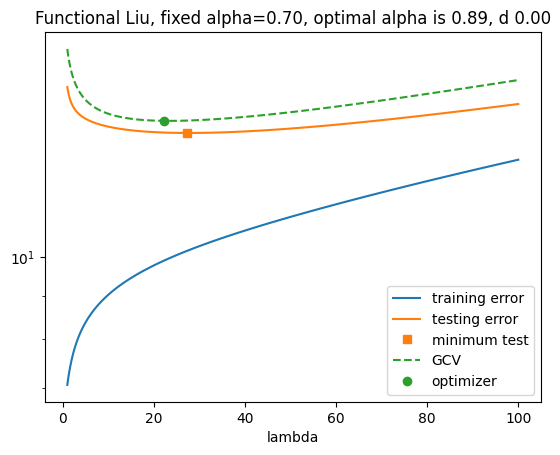

In [49]:
n   = 100
p   = 50
rho = 0.9

X, y, X_test, y_test = simulate_data(n,p, sigma2=10, rho=rho, seed=0 )
R = fliu.second_difference_matrix(p)
test_mse  = lambda beta : np.mean((X_test @ beta - y_test)**2)
train_mse = lambda beta : np.mean((X @ beta - y)**2)

# == Ridge ==
results_train = []
results_test  = []
results_gcv   = []
beta, gcv_opt, lam_opt = fliu.ridge(X,y ) # search for params
lambda_grid = np.logspace(0, 2, 100)
for lam in lambda_grid:
    beta, gcv = fliu.ridge(X,y, [lam] )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
title = f"Ridge, fixed alpha={alpha:.2f}, optimal alpha is {alpha:.2f}"
plot_results( results_train, results_test, results_gcv, lam_opt, gcv_opt, lambda_grid, title, x_label='lambda' )

# == Cardot ==
results_train = []
results_test  = []
results_gcv   = []
beta, gcv_opt, lam_opt, alpha_opt = fliu.cardot(X,y,R) # search for params
alpha = 1.1*alpha
for lam in lambda_grid:
    beta, gcv = fliu.cardot(X,y,R,(lam,alpha) )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
title = f"Cardot, fixed alpha={alpha:.2f}, optimal alpha is {alpha:.2f}"
plot_results( results_train, results_test, results_gcv, lam_opt, gcv_opt, lambda_grid, title, x_label='lambda' )

# == functional Liu ==
results_train = []
results_test  = []
results_gcv   = []
beta, gcv_opt, lam_opt, d_opt, alpha_opt = fliu.functional_liu(X,y,R) # search for params
d      = 1.3*d_opt  # fix any value
alpha  = 0.9*alpha_opt
for lam in lambda_grid:
    beta, gcv = fliu.functional_liu(X,y,R,(lam,d,alpha) )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
title = f"Functional Liu, fixed alpha={alpha:.2f}, optimal alpha is {alpha_optimal:.2f}, d {d:.2f}"
plot_results( results_train, results_test, results_gcv, lam_opt, gcv_opt, lambda_grid, title, x_label='lambda' )

### Further tests
Is GCV strongly correlated with test error?

In [29]:
n   = 100
p   = 50
rho = 0.9

X, y, X_test, y_test = simulate_data(n,p, sigma2=10, rho=rho, seed=0 )
R = fliu.second_difference_matrix(p)
test_mse  = lambda beta : np.mean((X_test @ beta - y_test)**2)
train_mse = lambda beta : np.mean((X @ beta - y)**2)

results_train = []
results_test  = []
results_gcv   = []
rng = np.random.default_rng(0)
for reps in range(int(3e2)):
    d     = rng.uniform(0,1)
    alpha = rng.uniform(0,1)
    lam   = 10**rng.uniform(0,2)
    beta, gcv = fliu.functional_liu(X,y,R,(lam,d,alpha) )[:2]
    results_train.append( train_mse(beta) )
    results_test.append(  test_mse(beta)  )
    results_gcv.append(   gcv             )
results_train = np.asarray(results_train)
results_test  = np.asarray(results_test)
results_gcv   = np.asarray(results_gcv)

Condition number of Sigma is 3.02e+02
SNR in dB is 10.28


Looks reasonable enough (**much** better than training loss)

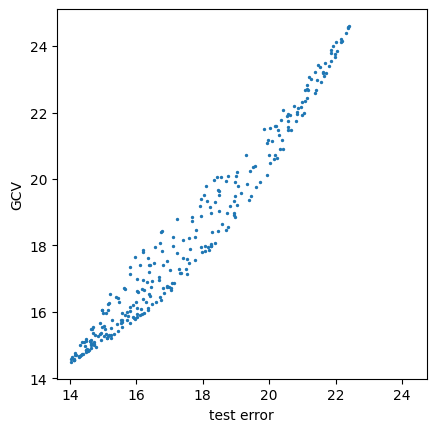

In [33]:
plt.scatter( results_test, results_gcv, s=2 )# ,label='GCV')
# plt.scatter( results_test, results_train, label='Training loss')
plt.xlabel('test error')
plt.ylabel('GCV')
plt.axis('square')
plt.show()